# **Project: E-commerce Customer Segmentation**
**Dataset:** UCI Online Retail II (2009–2011)  
**Goal:** Load the raw Excel file, clean it, and save a clean CSV for the next steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Load both sheets

In [2]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.xlsx to online_retail_II.xlsx


In [3]:
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

### Combine into one DataFrame

In [4]:
df = pd.concat([df1, df2], ignore_index=True)

In [5]:
len(df)

1067371

In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
df.shape

(1067371, 8)

In [8]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


In [9]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [10]:
df[['Quantity','Price']].describe()

,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


In [11]:
print('=== Data Quality Report ===')
print(f'Total rows:                  {len(df):>10,}')
print(f'Missing Customer ID:         {df["Customer ID"].isnull().sum():>10,}')
print(f'Cancelled invoices (C...):   {df[df["Invoice"].astype(str).str.startswith("C")].shape[0]:>10,}')
print(f'Negative quantity rows:      {(df["Quantity"] < 0).sum():>10,}')
print(f'Zero or negative price rows: {(df["Price"] <= 0).sum():>10,}')
print(f'Missing description:         {df["Description"].isnull().sum():>10,}')

=== Data Quality Report ===
Total rows:                   1,067,371
Missing Customer ID:            243,007
Cancelled invoices (C...):       19,494
Negative quantity rows:          22,950
Zero or negative price rows:      6,207
Missing description:              4,382


## Clean the data

In [13]:
df_clean = df.copy()

In [14]:
len(df_clean)

1067371

Remove rows with no Customer ID ---
We need Customer ID to group by customer. Without it, useless.

In [15]:
df_clean = df_clean.dropna(subset=['Customer ID'])
print(f'After removing missing Customer ID: {len(df_clean):,} rows')

After removing missing Customer ID: 824,364 rows


Remove cancelled transactions ---
Invoices starting with 'C' are cancellations (returns), not real sales.

In [16]:
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f'After removing cancellations:       {len(df_clean):,} rows')


After removing cancellations:       805,620 rows


Remove negative or zero quantities

In [17]:
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f'After removing bad quantities:      {len(df_clean):,} rows')

After removing bad quantities:      805,620 rows


Remove zero or negative prices

In [18]:
df_clean = df_clean[df_clean['Price'] > 0]
print(f'After removing bad prices:          {len(df_clean):,} rows')


After removing bad prices:          805,549 rows


In [19]:
print(f'Rows removed total: {len(df) - len(df_clean):,}')
print(f'Clean rows remaining: {len(df_clean):,}')

Rows removed total: 261,822
Clean rows remaining: 805,549


## Add useful columns

In [20]:
# TotalRevenue = how much money each line item made
df_clean['TotalRevenue'] = df_clean['Quantity'] * df_clean['Price']

In [21]:
# Make Customer ID an integer (it loaded as float)
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)


In [22]:
# Rename columns to remove the space (easier to work with in SQL)
df_clean = df_clean.rename(columns={'Customer ID': 'CustomerID'})


In [23]:
print('New columns added:')
print(df_clean.dtypes)
print()
df_clean[['Invoice', 'CustomerID', 'Quantity', 'Price', 'TotalRevenue']].head()


New columns added:
Invoice                 object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[ns]
Price                  float64
CustomerID               int64
Country                 object
TotalRevenue           float64
dtype: object



,Invoice,CustomerID,Quantity,Price,TotalRevenue
0,489434,13085,12,6.95,83.4
1,489434,13085,12,6.75,81.0
2,489434,13085,12,6.75,81.0
3,489434,13085,48,2.10,100.8
4,489434,13085,24,1.25,30.0


## Summary of clean data

In [24]:
print('=== Clean Data Summary ===')
print(f'Total transactions:   {len(df_clean):,}')
print(f'Unique customers:     {df_clean["CustomerID"].nunique():,}')
print(f'Unique products:      {df_clean["StockCode"].nunique():,}')
print(f'Unique countries:     {df_clean["Country"].nunique():,}')
print(f'Date range:           {df_clean["InvoiceDate"].min().date()} to {df_clean["InvoiceDate"].max().date()}')
print(f'Total revenue:        £{df_clean["TotalRevenue"].sum():,.2f}')
print(f'Avg order value:      £{df_clean.groupby("Invoice")["TotalRevenue"].sum().mean():,.2f}')


=== Clean Data Summary ===
Total transactions:   805,549
Unique customers:     5,878
Unique products:      4,631
Unique countries:     41
Date range:           2009-12-01 to 2011-12-09
Total revenue:        £17,743,429.18
Avg order value:      £479.95


## Visualizations


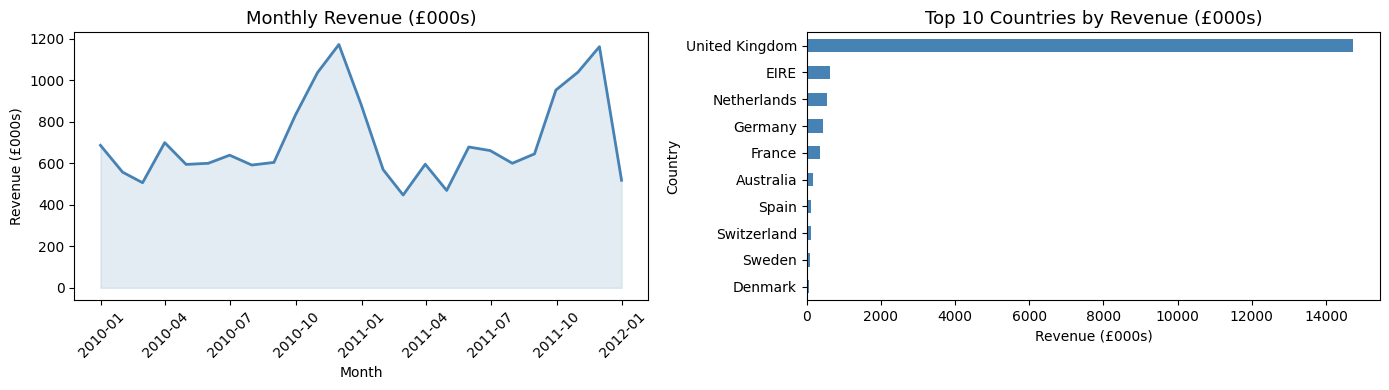

Chart saved!


In [27]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly revenue trend
monthly = df_clean.set_index('InvoiceDate').resample('ME')['TotalRevenue'].sum() / 1000
axes[0].plot(monthly.index, monthly.values, color='steelblue', linewidth=2)
axes[0].fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')
axes[0].set_title('Monthly Revenue (£000s)', fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (£000s)')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 countries by revenue
top_countries = df_clean.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head(10) / 1000
top_countries.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Countries by Revenue (£000s)', fontsize=13)
axes[1].set_xlabel('Revenue (£000s)')
axes[1].invert_yaxis()

plt.tight_layout()
os.makedirs('charts', exist_ok=True) # Ensure the directory exists
plt.savefig('charts/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

Save clean data to CSV

In [28]:
import os
os.makedirs('charts', exist_ok=True)
os.makedirs('data', exist_ok=True)



In [29]:
df_clean.to_csv('data/online_retail_clean.csv', index=False)


In [30]:
print('Clean data saved to: data/online_retail_clean.csv')
print(f'File contains {len(df_clean):,} rows and {len(df_clean.columns)} columns')
print()
print('Columns saved:', df_clean.columns.tolist())
print()
print('Step 1 COMPLETE. Ready for Step 2 (SQL setup).')


Clean data saved to: data/online_retail_clean.csv
File contains 805,549 rows and 9 columns

Columns saved: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'TotalRevenue']

Step 1 COMPLETE. Ready for Step 2 (SQL setup).


In [31]:
from google.colab import files
files.download('data/online_retail_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>